In [8]:
from typing import TypedDict

class ConversionState(TypedDict):
    amount_usd: float
    amount_inr: float
    amount_lkr: float

In [9]:
def convert_to_inr(state: ConversionState) -> ConversionState:
    state["amount_inr"] = state["amount_usd"] * 95.69
    return state

def convert_to_lkr(state: ConversionState) -> ConversionState:
    state["amount_lkr"] = state["amount_usd"] * 323.06
    return state

In [10]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ConversionState)

builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_node("convert_to_lkr_node", convert_to_lkr)

builder.add_edge(START, "convert_to_inr_node")
builder.add_edge("convert_to_inr_node", "convert_to_lkr_node")
builder.add_edge("convert_to_lkr_node", END)

graph = builder.compile()

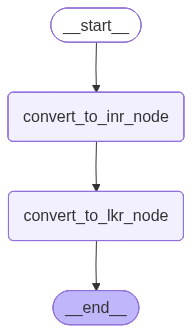

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"amount_usd": 1.00})

{'amount_usd': 1.0, 'amount_inr': 95.69, 'amount_lkr': 323.06}